In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, precision_score, recall_score

In [2]:
# Load Dataset

data = load_breast_cancer()

x = data.data
y = data.target
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
# Pandas to Dataframe

df = pd.DataFrame(x, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Select imp features 

selected_features = [
    "mean radius",
    "mean texture",
    "mean smoothness",
    "mean concavity",
    "mean symmetry"
]

df_small = df[selected_features + ["target"]]

df_small.head()

,mean radius,mean texture,mean smoothness,mean concavity,mean symmetry,target
0,17.99,10.38,0.11840,0.3001,0.2419,0
1,20.57,17.77,0.08474,0.0869,0.1812,0
2,19.69,21.25,0.10960,0.1974,0.2069,0
3,11.42,20.38,0.14250,0.2414,0.2597,0
4,20.29,14.34,0.10030,0.1980,0.1809,0


In [5]:
# Target Values

X = df_small[
    [
        "mean radius",
        "mean texture",
        "mean smoothness",
        "mean concavity",
        "mean symmetry"
    ]
]

y = df_small["target"]

In [6]:
# Train-Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Add constant for intercept

X_train_lm = sm.add_constant(X_train)
X_test_lm = sm.add_constant(X_test)

In [8]:
# GLM Model 

glm_model = sm.GLM(
    y_train,
    X_train_lm,
    family=sm.families.Binomial(link=sm.families.links.Logit())
)

glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                  455
Model:                            GLM   Df Residuals:                      449
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.936
Date:                Sat, 07 Mar 2026   Deviance:                       135.87
Time:                        20:46:26   Pearson chi2:                     321.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6397
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              38.8962      5.192     

In [9]:
# Prediction
y_pred_prob = glm_results.predict(X_test_lm)

In [10]:
# Metrics

y_pred = (y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465


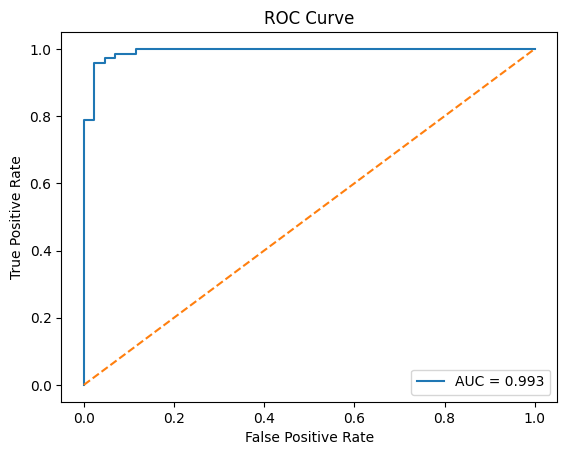

In [11]:
# Visualization (ROC)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.plot(fpr, tpr, label="AUC = " + str(round(auc,3)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()